In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from lazypredict.Supervised import LazyRegressor
from sklearn.preprocessing import StandardScaler

In [36]:
!pip install lazypredict
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
target = new_client.target
target_query = target.search('EGFR')
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,EGFR/PPP1CA,17.0,False,CHEMBL4523747,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
1,[],Homo sapiens,CCN2-EGFR,17.0,False,CHEMBL5465557,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
2,[],Mus musculus,Epidermal growth factor receptor,15.0,False,CHEMBL3608,"[{'accession': 'Q01279', 'component_descriptio...",SINGLE PROTEIN,10090
3,[],Mus musculus,Protein cereblon/Epidermal growth factor receptor,13.0,False,CHEMBL6193842,"[{'accession': 'Q01279', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,10090
4,[],Homo sapiens,Epidermal growth factor receptor,11.0,False,CHEMBL203,"[{'accession': 'P00533', 'component_descriptio...",SINGLE PROTEIN,9606
5,[],Homo sapiens,Protein cereblon/Epidermal growth factor receptor,11.0,False,CHEMBL4523680,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
6,[],Homo sapiens,Epidermal growth factor receptor,10.0,False,CHEMBL2363049,"[{'accession': 'P04626', 'component_descriptio...",PROTEIN FAMILY,9606
7,[],Homo sapiens,MER intracellular domain/EGFR extracellular do...,10.0,False,CHEMBL3137284,"[{'accession': 'P00533', 'component_descriptio...",CHIMERIC PROTEIN,9606
8,[],Homo sapiens,von Hippel-Lindau disease tumor suppressor/Epi...,10.0,False,CHEMBL4523998,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
9,[],Mus musculus,Protein cereblon/Epidermal growth factor receptor,10.0,False,CHEMBL6193841,"[{'accession': 'P00533', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,10090


In [35]:
if len(targets) == 0:
    raise ValueError("No targets found for STAT3 in ChEMBL database.")
selected_target = targets.target_chembl_id[6]
selected_target
chembl_id = targets.loc[targets['target_chembl_id'] == 'CHEMBL2363049']
print(chembl_id)
activity = new_client.activity.filter(target_chembl_id=selected_target)

if activity: 
    
    data = pd.DataFrame(activity)
    selected_columns = ['molecule_chembl_id', 'standard_type', 'standard_value', 'canonical_smiles']
    data = data[selected_columns]

    print(data.head()) 
else:
    print(f"Error: No bioactivity data found for target {selected_target}")
# Step 1: Data Preprocessing

# Drop rows with missing values in important column
data = data.dropna(subset=['standard_value', 'canonical_smiles'])

# Convert standard_value to numeric (handle any errors)
data['standard_value'] = pd.to_numeric(data['standard_value'], errors='coerce')

# Keep only IC50 bioactivity data
data = data[data['standard_type'] == 'IC50']

# Function to convert IC50 to pIC50
def ic50_to_pic50(value):
    return -np.log10(value * 1e-9) if value > 0 else np.nan  # Handle invalid values

# Apply the pIC50 conversion
data['pIC50'] = data['standard_value'].apply(ic50_to_pic50)

# Drop rows where pIC50 could not be calculated
data = data.dropna(subset=['pIC50'])

# Drop the original standard_value column (IC50)
data = data.drop(columns=['standard_value'])

# Display cleaned data
print(data.head())



  cross_references      organism                         pref_name  score  \
6               []  Homo sapiens  Epidermal growth factor receptor   10.0   

   species_group_flag target_chembl_id  \
6               False    CHEMBL2363049   

                                   target_components     target_type  tax_id  
6  [{'accession': 'P04626', 'component_descriptio...  PROTEIN FAMILY    9606  
  molecule_chembl_id standard_type standard_value  \
0       CHEMBL521179    Inhibition           10.0   
1       CHEMBL521179    Inhibition           10.0   
2       CHEMBL521179    Inhibition           10.0   
3       CHEMBL521179    Inhibition           10.0   
4       CHEMBL521179    Inhibition           10.0   

                                    canonical_smiles  
0  CN(C)CCOc1cc(-c2cn[nH]c2)ccc1NC(=O)C1COc2ccccc2O1  
1  CN(C)CCOc1cc(-c2cn[nH]c2)ccc1NC(=O)C1COc2ccccc2O1  
2  CN(C)CCOc1cc(-c2cn[nH]c2)ccc1NC(=O)C1COc2ccccc2O1  
3  CN(C)CCOc1cc(-c2cn[nH]c2)ccc1NC(=O)C1COc2ccccc2O1  
4  CN(C)

In [15]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# Step 2: Compute Molecular Descriptors

# Function to compute molecular descriptors
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)  # Convert SMILES to RDKit molecule
    if mol:  # Ensure the molecule is valid
        return [
            Descriptors.MolWt(mol),           # Molecular Weight
            Descriptors.MolLogP(mol),         # LogP (lipophilicity)
            Descriptors.NumHAcceptors(mol),   # Hydrogen Bond Acceptors
            Descriptors.NumHDonors(mol)       # Hydrogen Bond Donors
        ]
    else:
        return [np.nan, np.nan, np.nan, np.nan]  # Return NaN for invalid molecules

# Define descriptor names
descriptor_list = ['MolWt', 'MolLogP', 'NumHAcceptors', 'NumHDonors']

# Compute descriptors for all molecules
descriptor_data = data['canonical_smiles'].apply(compute_descriptors)

# Convert descriptor list into a DataFrame
descriptor_df = pd.DataFrame(descriptor_data.tolist(), columns=descriptor_list)

# Merge descriptors with original data
data = pd.concat([data, descriptor_df], axis=1)

# Drop the SMILES column (not needed for ML)
data = data.drop(columns=['canonical_smiles'])

# Display updated data
print(data.head())


   molecule_chembl_id standard_type     pIC50    MolWt  MolLogP  \
64       CHEMBL225519          IC50  5.000000  533.938   5.5265   
65      CHEMBL1256436          IC50  6.275724  616.018   4.6420   
66      CHEMBL1256435          IC50  7.065502  547.965   5.9166   
67      CHEMBL1256434          IC50  6.806875  475.475   2.9750   
68      CHEMBL1256433          IC50  7.200659  501.513   3.1620   

    NumHAcceptors  NumHDonors  
64            7.0         3.0  
65            9.0         4.0  
66            7.0         3.0  
67            8.0         2.0  
68            8.0         2.0  


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import joblib

# Step 3: Train a Machine Learning Model

# Drop any remaining missing values
data = data.dropna()

# Define features (X) and target (y)
X = data.drop(columns=['molecule_chembl_id', 'pIC50'])  # Use molecular descriptors as features
y = data['pIC50']  # Target variable

# Ensure only numerical data is used
X = X.select_dtypes(include=[np.number])

# Normalize the features (Scaling improves model performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Fixed: Manually compute RMSE

# Save the trained model
joblib.dump(model, 'random_forest_model.pkl')

# Print evaluation metrics
print(f'R-squared: {r2:.3f}')
print(f'RMSE: {rmse:.3f}')


R-squared: 0.081
RMSE: 0.626


In [17]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 5: Train the Model Using XGBoost

# Drop any remaining missing values
data = data.dropna()

# Define features (X) and target (y)
X = data.drop(columns=['molecule_chembl_id', 'pIC50'])  # Use molecular descriptors as features
y = data['pIC50']  # Target variable

# Ensure only numerical data is used
X = X.select_dtypes(include=[np.number])

# Normalize the features (Scaling improves model performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the XGBoost Regressor
model = XGBRegressor(
    n_estimators=500,        # Number of trees
    learning_rate=0.05,      # Controls step size
    max_depth=6,             # Tree depth
    subsample=0.8,           # Percentage of training samples used per tree
    colsample_bytree=0.8,    # Percentage of features used per tree
    random_state=42
)
model.fit(X_train, y_train)

# Save the trained model
joblib.dump(model, 'xgboost_model.pkl')

# Print completion message
print("✅ Model training completed. XGBoost model saved as 'xgboost_model.pkl'.")

# Print model summary
print("\n📌 Model Summary:")
print(model)


✅ Model training completed. XGBoost model saved as 'xgboost_model.pkl'.

📌 Model Summary:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 23, number of used features: 0
[LightGBM] [Info] Start training from score 6.351354
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spli

c:\Users\yaaga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


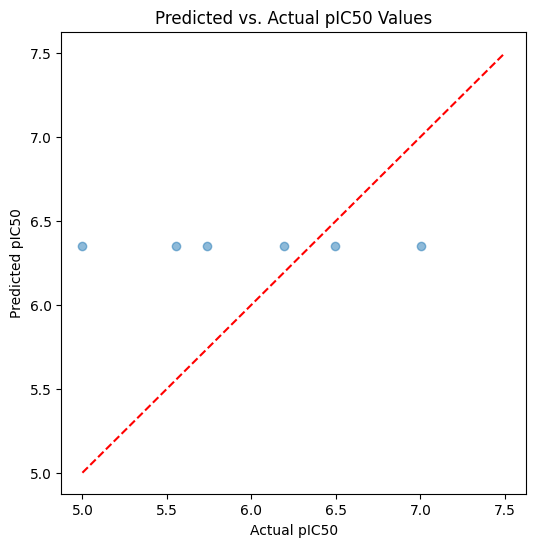

                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
AdaBoostRegressor                       -2.904456   0.219109  0.577236   
GradientBoostingRegressor               -3.041429   0.191714  0.587274   
ExtraTreesRegressor                     -3.500643   0.099871  0.619742   
RandomForestRegressor                   -3.658093   0.068381  0.630489   
BaggingRegressor                        -3.791509   0.041698  0.639454   
MLPRegressor                            -4.074913  -0.014983  0.658094   
SGDRegressor                            -4.845754  -0.169151  0.706307   
QuantileRegressor                       -4.915260  -0.183052  0.710494   
LGBMRegressor                           -5.477649  -0.295530  0.743502   
ElasticNet                              -5.477649  -0.295530  0.743502   
LassoLars                               -5.477649  -0.295530  0.743502   
LassoLarsCV                           

C:\Users\yaaga\AppData\Local\Temp\ipykernel_23780\297805243.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=models.index[:10], x=models['R-Squared'][:10], palette="viridis")


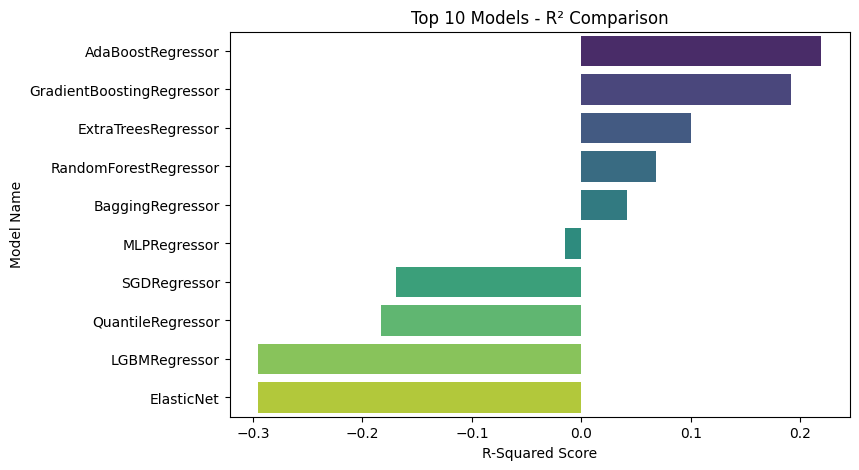

C:\Users\yaaga\AppData\Local\Temp\ipykernel_23780\297805243.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=models.index[:10], x=models['RMSE'][:10], palette="magma")


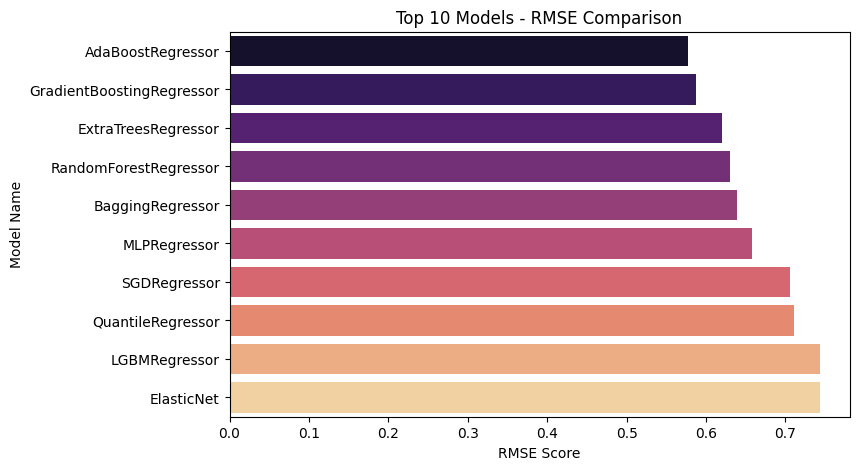

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyRegressor

# Drop any remaining missing values
data = data.dropna()

# Define features (X) and target (y)
X = data.drop(columns=['molecule_chembl_id', 'pIC50'])  # Use molecular descriptors as features
y = data['pIC50']  # Target variable

# Ensure only numerical data is used
X = X.select_dtypes(include=[np.number])

# Normalize the features (Scaling improves model performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the LGBM Regressor
model = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Compute RMSE manually

# Save the trained model
joblib.dump(model, 'lgbm_model.pkl')

# Print evaluation metrics
print(f'📊 LightGBM Model Evaluation:')
print(f'✅ R-squared (R²): {r2:.3f}')
print(f'✅ RMSE: {rmse:.3f}')

# ---- VISUALIZATION SECTION ----

# 1. Scatter Plot: Actual vs. Predicted Values
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Predicted vs. Actual pIC50 Values")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Reference line
plt.show()

# 2. Model Comparison Using Lazy Predict
lazy = LazyRegressor()
models, predictions = lazy.fit(X_train, X_test, y_train, y_test)
print(models)

# 3. R-Squared Values Comparison (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(y=models.index[:10], x=models['R-Squared'][:10], palette="viridis")
plt.xlabel("R-Squared Score")
plt.ylabel("Model Name")
plt.title("Top 10 Models - R² Comparison")
plt.show()

# 4. RMSE Values Comparison (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(y=models.index[:10], x=models['RMSE'][:10], palette="magma")
plt.xlabel("RMSE Score")
plt.ylabel("Model Name")
plt.title("Top 10 Models - RMSE Comparison")
plt.show()


In [20]:
!pip install lightgbm


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import joblib
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop any remaining missing values
data = data.dropna()

# Define features (X) and target (y)
X = data.drop(columns=['molecule_chembl_id', 'pIC50'])  # Use molecular descriptors as features
y = data['pIC50']  # Target variable

# Ensure only numerical data is used
X = X.select_dtypes(include=[np.number])

# Normalize the features (Scaling improves model performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the LGBM Regressor
model = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)
model.fit(X_train, y_train)

# Save the trained model
joblib.dump(model, 'lgbm_model.pkl')

print("✅ Model training completed. LightGBM model saved as 'lgbm_model.pkl'.")


✅ Model training completed. LightGBM model saved as 'lgbm_model.pkl'.


In [22]:
from lazypredict.Supervised import LazyRegressor
import time

# Step 6: Compare Multiple Models Using LazyPredict

# Initialize LazyRegressor
lazy = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Measure the time taken for model comparison
start_time = time.time()
models, predictions = lazy.fit(X_train, X_test, y_train, y_test)
end_time = time.time()

# Add the Time Taken column
models['Time Taken'] = end_time - start_time

# Rename columns for clarity
models = models.rename(columns={'Adjusted R-Squared': 'Adjusted R-Squared', 
                                'R-Squared': 'R-Squared', 
                                'RMSE': 'RMSE', 
                                'Time Taken': 'Time Taken'})

# Display the model comparison table
print(models)

# Save results to CSV
models.to_csv("model_comparison_results.csv")


                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
AdaBoostRegressor                       -2.904456   0.219109  0.577236   
GradientBoostingRegressor               -3.041429   0.191714  0.587274   
ExtraTreesRegressor                     -3.500643   0.099871  0.619742   
RandomForestRegressor                   -3.658093   0.068381  0.630489   
BaggingRegressor                        -3.791509   0.041698  0.639454   
MLPRegressor                            -4.074913  -0.014983  0.658094   
SGDRegressor                            -4.845754  -0.169151  0.706307   
QuantileRegressor                       -4.915260  -0.183052  0.710494   
LGBMRegressor                           -5.477649  -0.295530  0.743502   
ElasticNet                              -5.477649  -0.295530  0.743502   
LassoLars                               -5.477649  -0.295530  0.743502   
LassoLarsCV                           

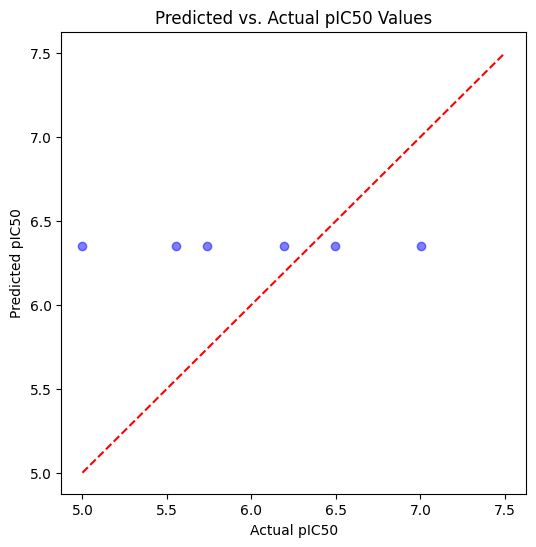

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Reference line
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Predicted vs. Actual pIC50 Values")
plt.show()


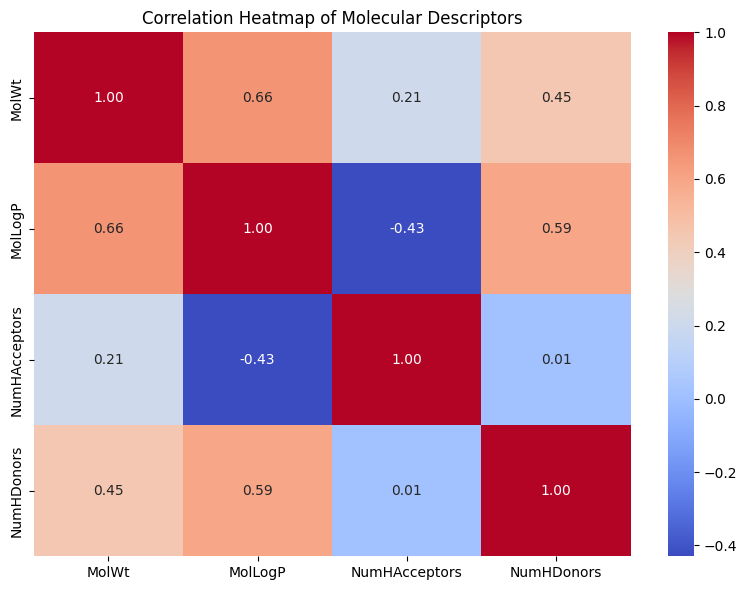

In [27]:
plt.figure(figsize=(8, 6))

corr_matrix = (
    data.drop(columns=['molecule_chembl_id', 'pIC50'], errors='ignore')
        .select_dtypes(include=[np.number])
        .corr()
)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap of Molecular Descriptors")
plt.tight_layout()
plt.show()

In [ ]:
print(data.dtypes)


molecule_chembl_id     object
standard_type          object
pIC50                 float64
MolWt                 float64
MolLogP               float64
NumHAcceptors         float64
NumHDonors            float64
dtype: object


C:\Users\yaaga\AppData\Local\Temp\ipykernel_23780\1039223092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=models.index[:10], x=models['R-Squared'][:10], palette="viridis")


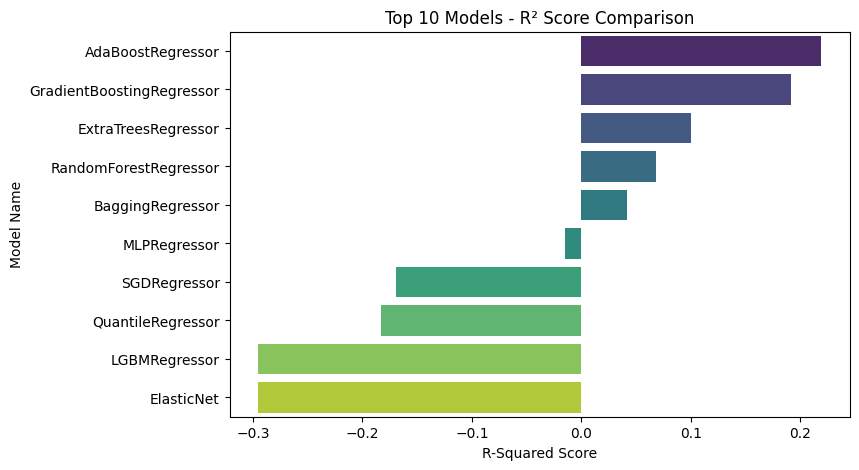

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(y=models.index[:10], x=models['R-Squared'][:10], palette="viridis")
plt.xlabel("R-Squared Score")
plt.ylabel("Model Name")
plt.title("Top 10 Models - R² Score Comparison")
plt.show()

C:\Users\yaaga\AppData\Local\Temp\ipykernel_23780\4278558011.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=models.index[:10], x=models['RMSE'][:10], palette="magma")


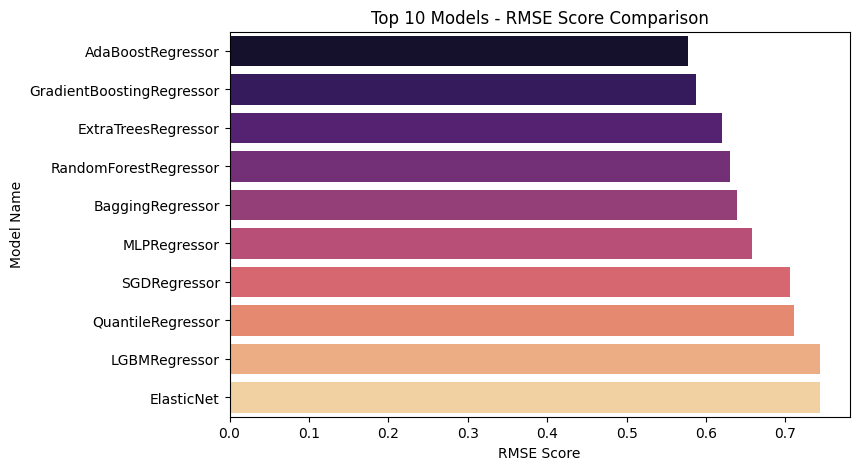

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(y=models.index[:10], x=models['RMSE'][:10], palette="magma")
plt.xlabel("RMSE Score")
plt.ylabel("Model Name")
plt.title("Top 10 Models - RMSE Score Comparison")
plt.show()

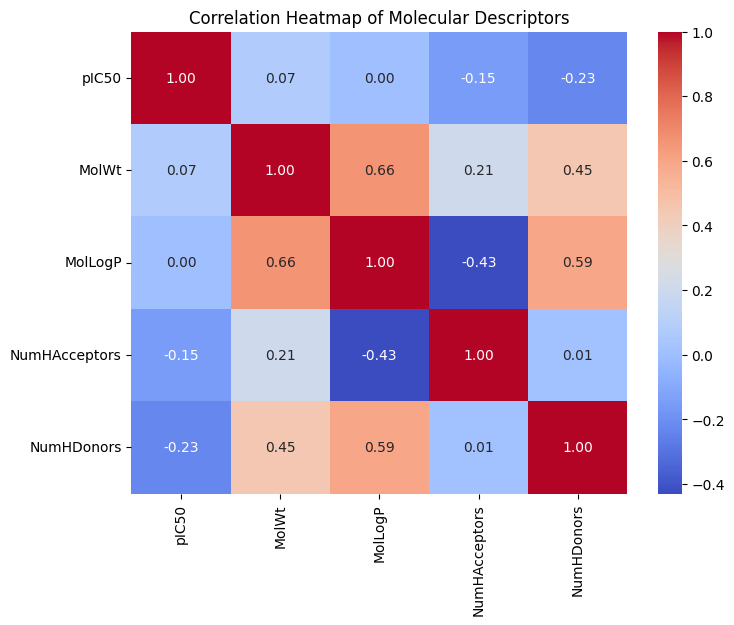

In [30]:
# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=[np.number])

# Generate the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Molecular Descriptors")
plt.show()
